# AG-HYPOPT · Trial 12

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Eleven trials recorded; best is trial 11 (0.0174). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174. Trials 05/07/08/09/10/11 are all the same plateau point (lr_mu ~27, sigma_ref ~6.1-6.3, lr_gamma ~0.42, gamma_anneal ~0.39-0.42); their objectives span 0.0174-0.0301 purely through the low-count Trans05 gamma noise, and with six samples the best has crept down (0.0196 -> 0.0182 -> 0.0174) as more runs land on the good side. mu sits at 14.4-17.2%, gamma at 11.6-18.5%. No hyperparameter value has beaten the plateau; lr_mu peaks near 27 and sigma_ref is monotone (smaller better, saturated just below ~6.3). We are in the TPE phase (12th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_12'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (11/5 trials)
ID |     ei | params
 1 | 3.9465 | {"gamma_anneal": 0.4231981723302792, "lr_gamma": 0.3434331283344861, "lr_mu": 26.891196658286734, "sigma_ref": 6.108730706067118}
 2 | 3.1178 | {"gamma_anneal": 0.4257458690706559, "lr_gamma": 0.6331729293750354, "lr_mu": 11.448873969024756, "sigma_ref": 6.2231736057089755}
 3 | 3.9999 | {"gamma_anneal": 0.4223440043014625, "lr_gamma": 0.41814635590395904, "lr_mu": 27.04580109265348, "sigma_ref": 6.278558473633272}
 4 | 3.9941 | {"gamma_anneal": 0.7025220936968503, "lr_gamma": 0.41852327329691236, "lr_mu": 26.875673853810806, "sigma_ref": 6.25305602447657}
 5 | 0.8087 | {"gamma_anneal": 0.40445843603394566, "lr_gamma": 0.8109000717101371, "lr_mu": 28.64001703246515, "sigma_ref": 17.00220571059202}
 6 | 3.9855 | {"gamma_anneal": 0.40890376801184886, "lr_gamma": 0.8243062410344839, "lr_mu": 27.016284567731233, "sigma_ref": 6.07876718085554}
 7 | 3.9086 | {"gamma_anneal": 0.3948582430933, "lr_gamma": 0.4174286367271904, "lr_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 11 (0.0174); the plateau config (lr_mu ~27, sigma_ref ~6.2) has now been run six times with objectives 0.0174-0.0301, all the spread being Trans05 gamma noise. The TPE batch once more proposes the plateau: #3 (ei 3.9999, lr_mu 27.05, sigma_ref 6.279) and #8 (ei 3.9999, lr_mu 26.99, sigma_ref 6.093) are the top draws and are effectively the same point, with #8 carrying the lowest sigma_ref in the batch. Since sigma_ref is monotone in mu error and the plateau's lower edge has not been probed below 6.1, the marginally more informative choice is the top-ei draw with the smallest sigma_ref, candidate 8 (lr_mu 26.99, sigma_ref 6.093, lr_gamma 0.419, gamma_anneal 0.427) - it is the model's joint-best and nudges sigma_ref to the low end of the good region. Candidates 4/6 (gamma_anneal 0.70, lr_gamma 0.82) probe the gamma direction, which has never helped. I choose candidate 8.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4272561607959156, 'lr_gamma': 0.41853440469083536, 'lr_mu': 26.99136438143308, 'sigma_ref': 6.092670751287152}
Running  1nW Trans05 ... 

μ 9.39 -> 6.90 | γ 8.5 -> 6.87 | NLL 1.32


Running  1nW Trans20 ... 

μ 17.32 -> 15.86 | γ 8.5 -> 7.92 | NLL 2.75


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 98.97 | γ 14.1 -> 13.79 | NLL 3.42


Running 3nW Trans100 ... 

μ 175.71 -> 164.15 | γ 14.1 -> 13.95 | NLL 2.89



Total: 7.1 min


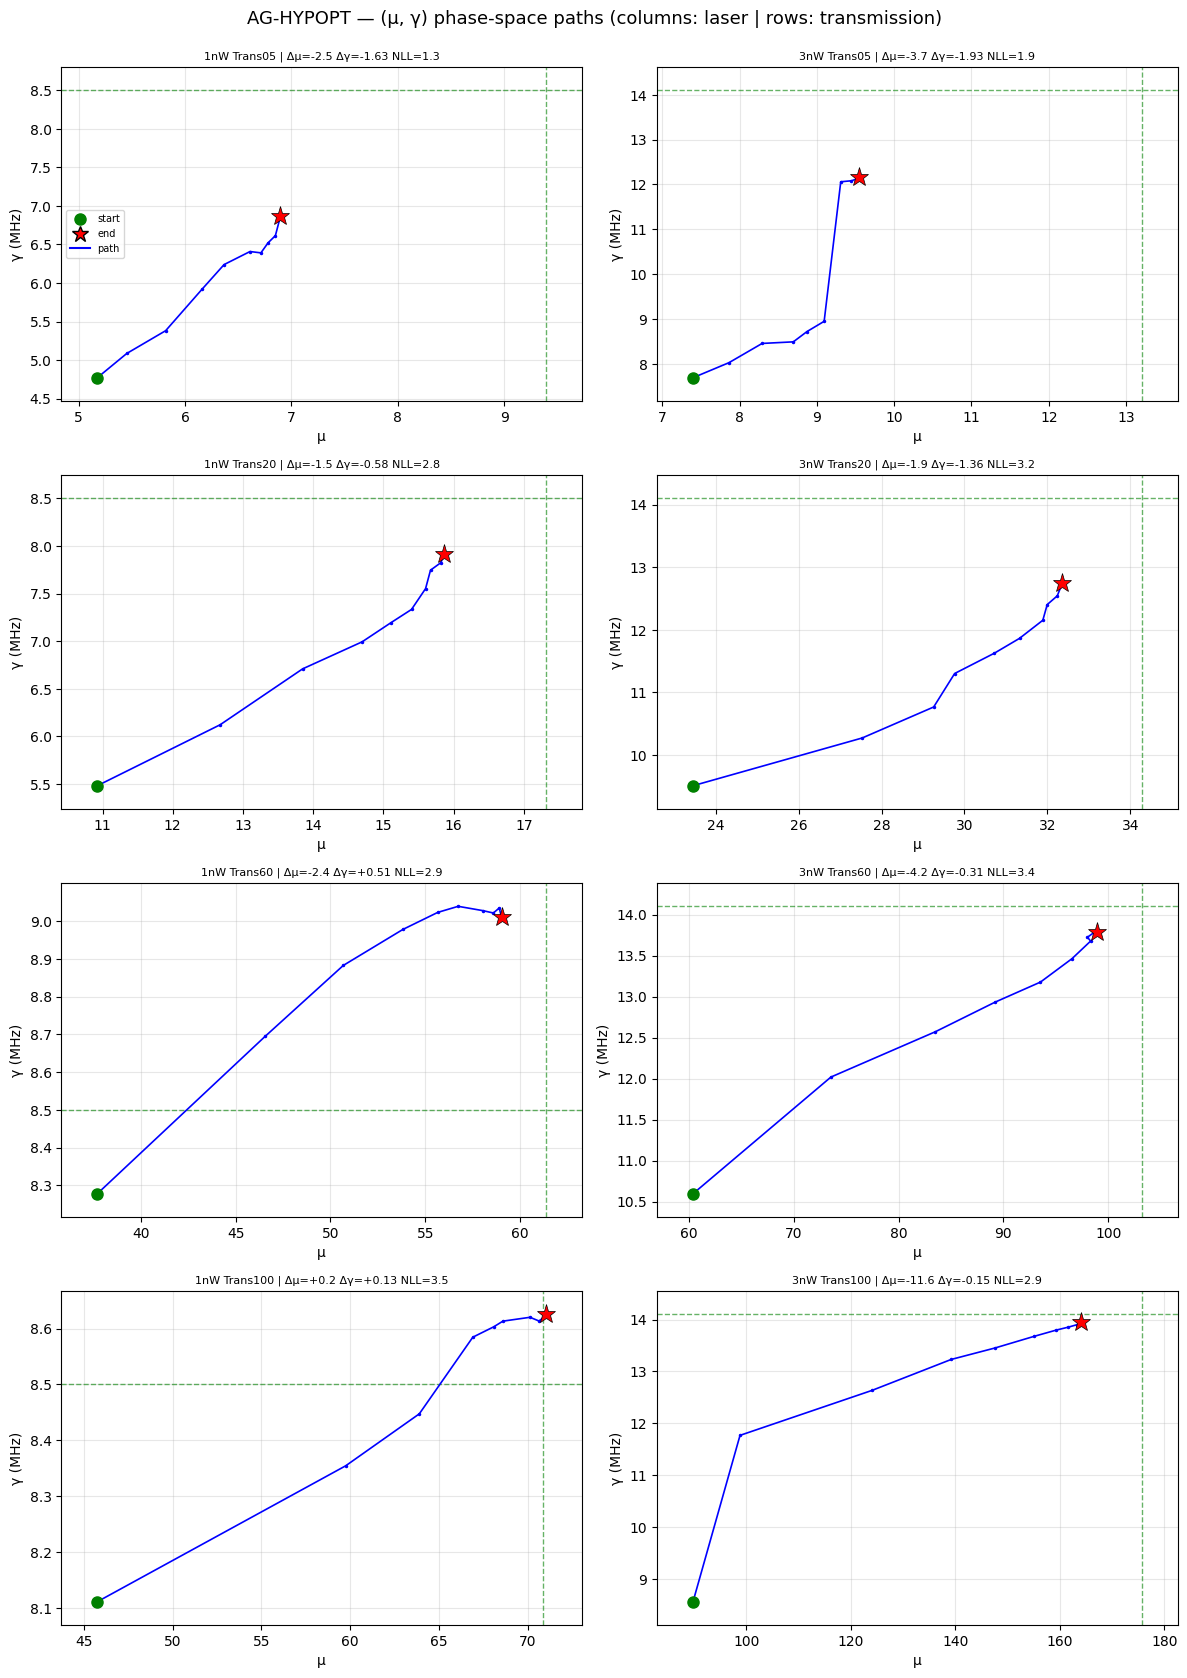

trial finished in 7.1 min
objective = 0.0150 ± 0.0062
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.90   -26.6 |     8.50    6.87   -19.2
1nW Trans20    17.32   15.86    -8.4 |     8.50    7.92    -6.8
1nW Trans60    61.37   59.02    -3.8 |     8.50    9.01    +6.0
1nW Trans100   70.82   71.01    +0.3 |     8.50    8.63    +1.5
3nW Trans05    13.20    9.54   -27.7 |    14.10   12.17   -13.7
3nW Trans20    34.28   32.36    -5.6 |    14.10   12.74    -9.6
3nW Trans60   103.20   98.97    -4.1 |    14.10   13.79    -2.2
3nW Trans100  175.71  164.15    -6.6 |    14.10   13.95    -1.1

μ: RMSE 4.776 (rel 14.4%, bias -3.435) | γ: RMSE 1.059 (rel 9.6%, bias -0.666)


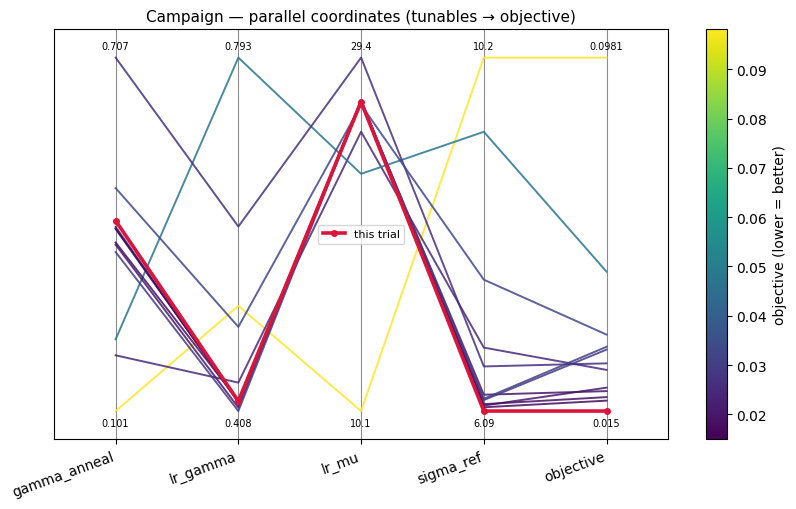

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 12 (sigma_ref 6.093, lr_mu 26.99, lr_gamma 0.419, gamma_anneal 0.427) - the top-ei draw with the lowest sigma_ref in the TPE batch - ran 7.1 min and scored 0.0150 +/- 0.0062, a new best with the lowest uncertainty yet. mu is 14.4% (at the floor) and gamma 9.6%, by far the best gamma (previous best 11.6%): 3nW Trans05 gamma improved to -13.7% (versus about -29% in most runs) and 1nW Trans20 to -6.8%. This run has sigma_ref at the low edge of the good region (6.09), consistent with sigma_ref being monotone in gamma error too, though part of the gamma gain may still be run-to-run Trans05 noise. Six runs of the plateau config now span 0.0150-0.0301; the best keeps improving as more samples land, and trial 12 is the current best config: lr_mu ~27, sigma_ref ~6.1, lr_gamma ~0.42, gamma_anneal ~0.43.

**Summary:** Trial 12 (sigma_ref 6.093, lr_mu 26.99, lr_gamma 0.419, gamma_anneal 0.427) scored 0.0150 +/- 0.0062, a clear new best with the best gamma so far (9.6%) and mu at the 14.4% floor - the lowest sigma_ref of the plateau points.
**Key insight:** Pushing sigma_ref to the low edge of the good region (6.09) coincided with the best gamma yet (9.6%), so sigma_ref may be monotone in gamma error too; the best config is lr_mu ~27, sigma_ref ~6.1.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 12 (sigma_ref 6.093, lr_mu 26.99, lr_gamma 0.419, gamma_anneal 0.427) scored 0.0150 +/- 0.0062, a clear new best with the best gamma so far (9.6%) and mu at the 14.4% floor - the lowest sigma_ref of the plateau points.'
KEY_INSIGHT = 'Pushing sigma_ref to the low edge of the good region (6.09) coincided with the best gamma yet (9.6%), so sigma_ref may be monotone in gamma error too; the best config is lr_mu ~27, sigma_ref ~6.1.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_12 | current best: trial_12


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_13.ipynb. Open it and follow its cells from the top.
